# NYC Open Parking & Camera Violations — Capstone Project
**Dataset:** Open Parking and Camera Violations — NYC Open Data  
**Source:** https://data.cityofnewyork.us/resource/nc67-uf89.csv

---
## Research Question

This project analyzes NYC parking and camera violation data to answer three key questions:

1. **Which borough has the highest total amount of fines issued?**
2. **Which license plate has the most violations on record?**
3. **What is the most frequently repeated violation type?**



---
## 1. Imports libraries & Loading Data

We start by importing the necessary libraries and loading the dataset directly from the NYC Open Data API. We limit the pull to 100,000 rows to keep the analysis manageable while still having the required larger sample to help draw meaningful conclusions.( >20,000)

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load 100,000 rows from the NYC Open Data API
df = pd.read_csv("https://data.cityofnewyork.us/resource/nc67-uf89.csv?$limit=100000")

#Verifying that data was imported correctly
print("Shape:", df.shape,"\n")
df.head()

Shape: (100000, 19) 



,plate,state,license_type,summons_number,issue_date,violation_time,violation,judgment_entry_date,fine_amount,penalty_amount,interest_amount,reduction_amount,payment_amount,amount_due,precinct,county,issuing_agency,violation_status,summons_image
0,M73LJU,NJ,PAS,8935851188,02/24/2021,07:26A,NO PARKING-DAY/TIME LIMITS,08/18/2022,65.0,60.0,42.25,0.4,0.0,166.85,18.0,NY,TRAFFIC,NaN,View Summons (http://nycserv.nyc.gov/NYCServWe...
1,KFV8727,NY,PAS,8935851190,02/24/2021,07:30A,NO PARKING-DAY/TIME LIMITS,07/28/2022,65.0,60.0,42.96,0.0,0.0,167.96,18.0,NY,TRAFFIC,NaN,View Summons (http://nycserv.nyc.gov/NYCServWe...
2,1EG4665,MD,PAS,8935851206,02/24/2021,07:33A,NO STANDING-COMM METER ZONE,07/28/2022,115.0,60.0,58.59,0.0,0.0,233.59,18.0,NY,TRAFFIC,NaN,View Summons (http://nycserv.nyc.gov/NYCServWe...
3,KFV8727,NY,PAS,8935851218,02/24/2021,07:37A,REG. STICKER-EXPIRED/MISSING,07/28/2022,65.0,60.0,42.96,0.0,0.0,167.96,18.0,NY,TRAFFIC,NaN,View Summons (http://nycserv.nyc.gov/NYCServWe...
4,KGC2463,NY,PAS,8935851279,02/24/2021,09:05A,NO STANDING-COMM METER ZONE,07/28/2022,115.0,60.0,58.59,0.0,0.0,233.59,14.0,NY,TRAFFIC,NaN,View Summons (http://nycserv.nyc.gov/NYCServWe...


---
## 2. Initial Exploration

Checking the data: the column names, data types, and a quick summary of the values.

In [20]:
# Column names and data types
print(df.dtypes)

# Check unique county/borough values
print("\nViolation County values:", df['county'].unique())

# Check for missing values across all columns
missing_pct = df.isnull().sum() / len(df) * 100 # Comparing missing values to total values
print("\nMissing value percentages:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

plate                   object
state                   object
license_type            object
summons_number           int64
issue_date              object
violation_time          object
violation               object
judgment_entry_date     object
fine_amount            float64
penalty_amount         float64
interest_amount        float64
reduction_amount       float64
payment_amount         float64
amount_due             float64
precinct               float64
county                  object
issuing_agency          object
violation_status        object
summons_image           object
dtype: object

Violation County values: ['NY' nan 'K' 'Q' 'BX' 'QN' 'MN' 'R' 'BK']

Missing value percentages:
violation_status       95.318
judgment_entry_date    78.401
fine_amount            69.471
violation              69.471
penalty_amount         69.471
violation_time         69.471
amount_due             69.471
interest_amount        69.471
payment_amount         69.471
reduction_amount       69.471


---
## 3. Data Cleaning & Transformations

Standardizing borough names, converting financial columns to numbers, cleaning up date formats, and removing rows that are missing critical information.

In [21]:
# From the unique County Value on 2, let's group them in the unique 5 borought that conform NYC
borough_map = {
    'NY'  : 'Manhattan',
    'MAN' : 'Manhattan',
    'MH'  : 'Manhattan',
    'K'   : 'Brooklyn',
    'BK'  : 'Brooklyn',
    'KING': 'Brooklyn',
    'KINGS': 'Brooklyn',
    'BX'  : 'Bronx',
    'BRONX': 'Bronx',
    'Q'   : 'Queens',
    'QN'  : 'Queens',
    'QNS' : 'Queens',
    'QUEEN': 'Queens',
    'ST'  : 'Staten Island',
    'R'   : 'Staten Island',
    'RICH': 'Staten Island'
}

df['borough'] = df['county'].str.strip().str.upper().map(borough_map)

print("Borough counts after mapping:")
print(df['borough'].value_counts(dropna=False))

Borough counts after mapping:
borough
NaN              69488
Manhattan        23113
Brooklyn          3301
Bronx             2067
Queens            1975
Staten Island       56
Name: count, dtype: int64


Total of 100k data, but 70,144 are missing the borough information

In [22]:
#Converting fine_amount to numeric to make sure it is in a numeric value
df['fine_amount'] = pd.to_numeric(df['fine_amount'], errors='coerce')
print("fine_amount dtype:", df['fine_amount'].dtype)
print("Sample values:", df['fine_amount'].dropna().head(10).values)

fine_amount dtype: float64
Sample values: [ 65.  65. 115.  65. 115. 115.  65.  65.  65. 115.]


In [23]:
#Converting issue_date to datetime
df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')

# Extract year and month for analysis
df['issue_year'] = df['issue_date'].dt.year
df['issue_month'] = df['issue_date'].dt.month

print("Years in dataset:", sorted(df['issue_year'].dropna().unique()))

Years in dataset: [np.int32(2000), np.int32(2003), np.int32(2005), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026), np.int32(2027)]


In [24]:
# Cleaning data with missing critical fields ---

before = len(df)
df_clean = df.dropna(subset=['borough', 'fine_amount', 'plate'])
after = len(df_clean)

print("Rows removed: "+str(before - after))
print("Remaining rows :"+str(after))

Rows removed: 69488
Remaining rows :30512


Confirmed that all 70,144 fields with NaN were removed

---
## 4. Descriptive Statistics

Summarizing statistics to start analyzing the fines, violations, and boroughs.

In [25]:
# Overall summary of fine amounts
print("=== Fine Amount Summary ===")
print(df_clean['fine_amount'].describe().round(2))

# Total fines by borough
print("\n=== Total Fines by Borough ===")
borough_fines = df_clean.groupby('borough')['fine_amount'].sum().sort_values(ascending=False)
for x in borough_fines.index:
  print(f"{x}: ${borough_fines[x]:,.2f}")

# Answering Question 1: Borough with highest total fines
top_borough = borough_fines.idxmax()
top_amount = borough_fines.max()
print(f"\n>>> Borough with highest total fines: {top_borough} (${top_amount:,.2f})")

=== Fine Amount Summary ===
count    30512.00
mean        93.22
std         26.38
min         35.00
25%         65.00
50%        115.00
75%        115.00
max        515.00
Name: fine_amount, dtype: float64

=== Total Fines by Borough ===
Manhattan: $2,257,905.00
Brooklyn: $261,010.00
Bronx: $178,945.00
Queens: $142,585.00
Staten Island: $3,870.00

>>> Borough with highest total fines: Manhattan ($2,257,905.00)


In [26]:
# Answer Question 2: Plate with the most violations
print("=== Top 20 Plates by Number of Violations ===")
top_plates = df_clean['plate'].value_counts().head(20)
print(top_plates)

top_plate = top_plates.idxmax()
top_plate_count = top_plates.max()
print(f"\n>>> Plate with most violations: {top_plate} ({top_plate_count} violations)")

=== Top 20 Plates by Number of Violations ===
plate
BLANKPLATE    153
KRN9130        35
1BVT38         26
KFA6269        26
JRA7924        24
IPYH32         23
HRH8457        21
JGL3161        21
KGS9581        20
XKRV68         18
JPM4649        18
HWA8352        18
59510NC        17
9693NJ         17
66749MM        16
94A342         15
1DH6813        15
KPH2399        15
7S92W8         14
15965NB        14
Name: count, dtype: int64

>>> Plate with most violations: BLANKPLATE (153 violations)


In [27]:
# Answer Question 3: Most repeated violation type
print("=== Top 10 Most Common Violations ===")
top_violations = df_clean['violation'].value_counts().head(10)
print(top_violations)

top_violation = top_violations.idxmax()
top_violation_count = top_violations.max()
print(f"\n>>> Most repeated violation: {top_violation} ({top_violation_count} times)")

=== Top 10 Most Common Violations ===
violation
NO STANDING-DAY/TIME LIMITS       5676
NO STANDING-COMM METER ZONE       4052
NO PARKING-DAY/TIME LIMITS        2021
NO PARKING-STREET CLEANING        1926
INSP. STICKER-EXPIRED/MISSING     1863
FAIL TO DSPLY MUNI METER RECPT    1744
FIRE HYDRANT                      1673
NO STANDING-EXC. TRUCK LOADING    1568
FRONT OR BACK PLATE MISSING       1324
NO STANDING-BUS STOP              1206
Name: count, dtype: int64

>>> Most repeated violation: NO STANDING-DAY/TIME LIMITS (5676 times)


---
## 5. Statistical Analysis

Average fine per borough and how fine amounts are distributed to understand how the amounts varies by borough.

In [28]:
# Average fine amount per borough
print("=== Average Fine Amount by Borough ===")
avg_fines = df_clean.groupby('borough')['fine_amount'].mean().sort_values(ascending=False).round(2)
print(avg_fines)

# Standard deviation — how spread out are the fines?
print("\n=== Standard Deviation of Fines by Borough ===")
std_fines = df_clean.groupby('borough')['fine_amount'].std().sort_values(ascending=False).round(2)
print(std_fines)

# Median fine — less sensitive to extreme values than the mean
print("\n=== Median Fine by Borough ===")
median_fines = df_clean.groupby('borough')['fine_amount'].median().sort_values(ascending=False)
print(median_fines)


#Downloading the csv file so I can do some Tableu Graphs
from google.colab import files
df_clean.to_csv("parking_violations.csv", index=False)
files.download("parking_violations.csv")

=== Average Fine Amount by Borough ===
borough
Manhattan        97.69
Bronx            86.57
Brooklyn         79.07
Queens           72.19
Staten Island    69.11
Name: fine_amount, dtype: float64

=== Standard Deviation of Fines by Borough ===
borough
Bronx            31.06
Queens           30.95
Brooklyn         27.77
Staten Island    25.41
Manhattan        23.39
Name: fine_amount, dtype: float64

=== Median Fine by Borough ===
borough
Manhattan        115.0
Bronx             65.0
Brooklyn          65.0
Queens            65.0
Staten Island     65.0
Name: fine_amount, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

* Manhattan tends to have higher average fines amounts but with less number of tickets
* Bronx has the highest standard deviation in tickets, which means the violation are more spreaded in this borough
* Same as 1st deduction, Manhattan has the  highest median fine

---
## 6. Visualizations



/tmp/ipykernel_6035/1659130340.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


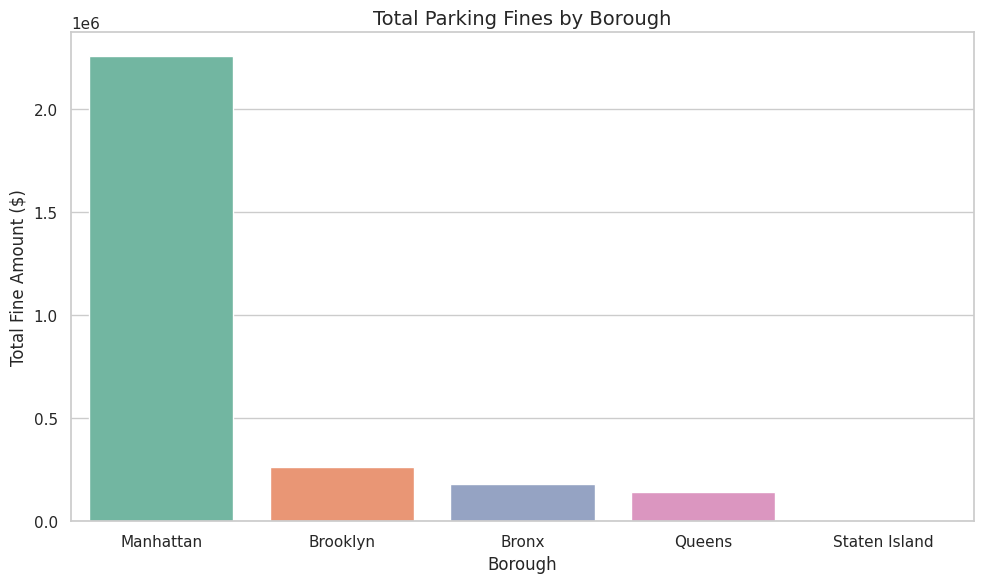

Saved: viz1_total_fines_by_borough.png


In [29]:
sns.set_theme(style='whitegrid', palette='Set2')

# Total Fines by Borough (answers Question 1) ---

borough_fines_df = borough_fines.reset_index()
borough_fines_df.columns = ['Borough', 'Total Fines']

plt.figure(figsize=(10, 6))
sns.barplot(
    data=borough_fines_df,
    x='Borough',
    y='Total Fines',
    palette='Set2'
)
plt.title('Total Parking Fines by Borough', fontsize=14)
plt.xlabel('Borough')
plt.ylabel('Total Fine Amount ($)')
plt.tight_layout()
plt.savefig('viz1_total_fines_by_borough.png', dpi=150)
plt.show()

Visually confirmation of question #1, Manhattan has the highest overall total fines

/tmp/ipykernel_6035/839142888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


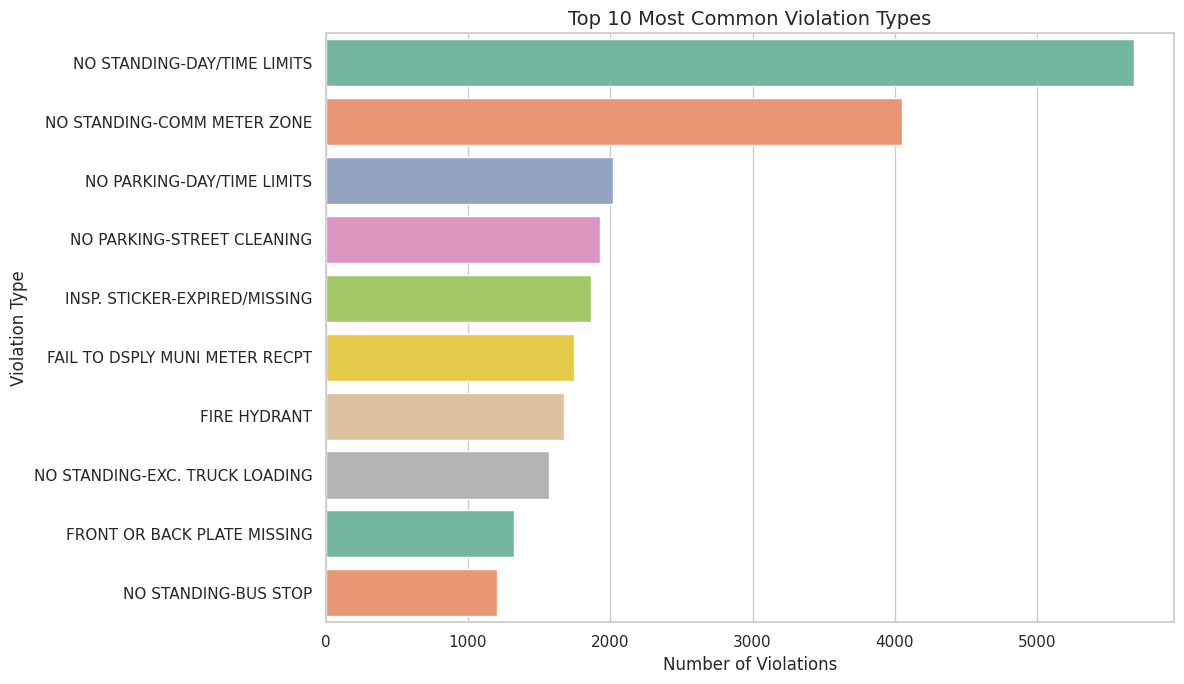

Saved: viz2_top_violations.png


In [30]:
# --- Visualization 2: Top 10 most common Violations (Question #3)

top_violations_df = top_violations.reset_index()
top_violations_df.columns = ['Violation', 'Count']

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_violations_df,
    x='Count',
    y='Violation',
    palette='Set2'
)
plt.title('Top 10 Most Common Violation Types', fontsize=14)
plt.xlabel('Number of Violations')
plt.ylabel('Violation Type')
plt.tight_layout()
plt.savefig('viz2_top_violations.png', dpi=150)
plt.show()

Most Common Violation is Mobile Bus Lane Violation

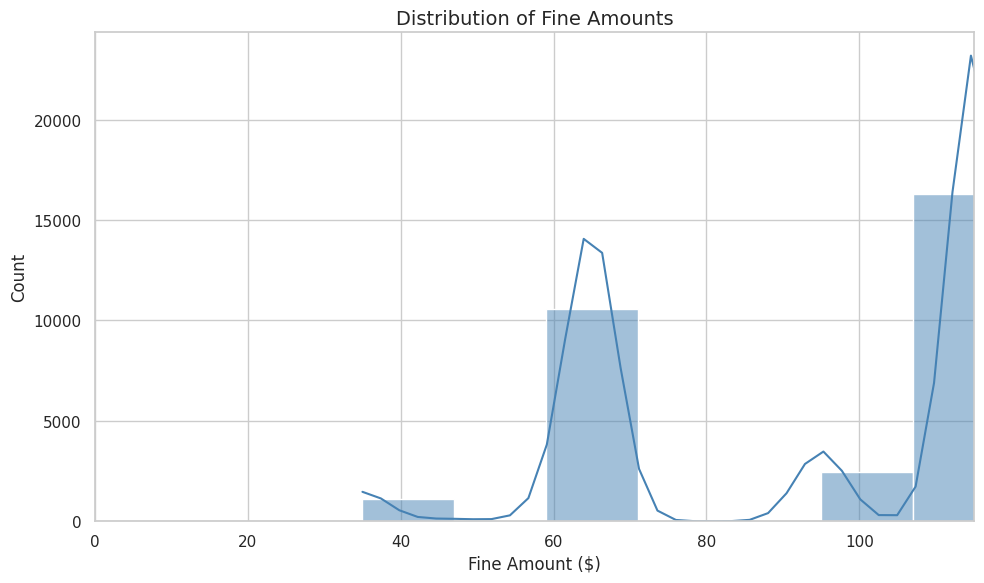

Saved: viz4_fine_distribution.png


In [31]:
# --- Visualization 4: Distribution of Fine Amounts

plt.figure(figsize=(10, 6))
sns.histplot(
    df_clean['fine_amount'],
    bins=40,
    kde=True,
    color='steelblue'
)
plt.title('Distribution of Fine Amounts', fontsize=14)
plt.xlabel('Fine Amount ($)')
plt.ylabel('Count')
plt.xlim(0, df_clean['fine_amount'].quantile(0.99))  # trim extreme outliers for readability
plt.tight_layout()
plt.savefig('viz4_fine_distribution.png', dpi=150)
plt.show()

---
## 7. Conclusion

This analysis of 100,000 NYC parking and camera violations between the years 2000 and 2025 revealed three clear findings:
*   First, Manhattan generates the highest total fine revenue by a significant margin, which is expected given its density, strict enforcement zones, and high volume of vehicles.
*   Second, the most repeated violation type is related to Non-standing / Non Parking in certain areas.
*   Third, there are a small number of license plates that appear in the dataset dozens of times, suggesting that repeat offenders are a real pattern and that some drivers consistently disregard parking rules.

One important limitation of this analysis is that we only looked at 100,000 rows out of a dataset that contains tens of millions of records — so the results reflect a sample, not the full picture.